<a href="https://colab.research.google.com/github/Uzema/dsp-seminars/blob/nikolaev_lab2/seminars/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

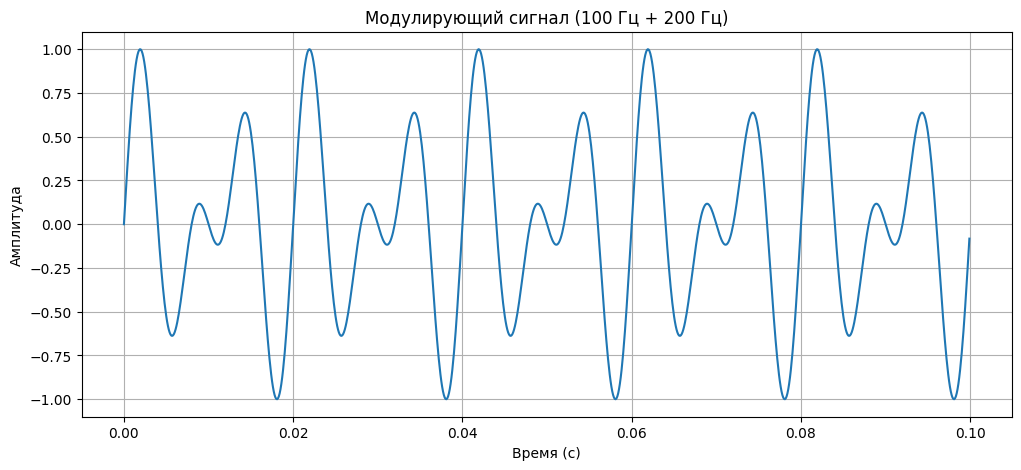

In [147]:
fm1 = 100
fm2 = 150
m_t = Ac * np.sin(2 * np.pi * fm1 * t ) + Ac * np.sin(2 * np.pi * fm2 * t ) # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]
m_t = m_t / np.max(np.abs(m_t))

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [148]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [149]:
beta_pm = 5
s_pm = Ac * np.cos(2*np.pi*fc*t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

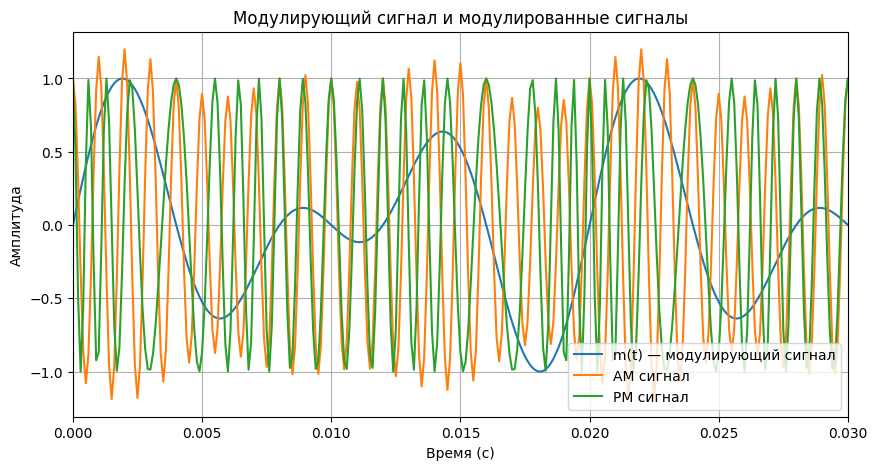

In [150]:
plt.figure(figsize=(10, 5))

plt.plot(t, m_t,  label='m(t) — модулирующий сигнал')
plt.plot(t, s_am, label='AM сигнал')
plt.plot(t, s_pm,  label='PM сигнал')

plt.title('Модулирующий сигнал и модулированные сигналы')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')

plt.legend(loc='lower right')
plt.grid(True)

plt.xlim(0, 0.03)

plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

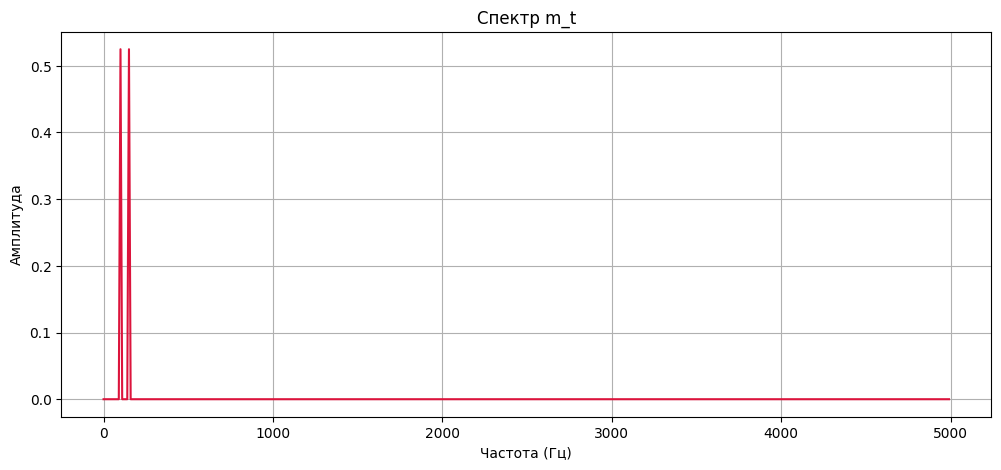

In [151]:
def plot_spectrum(s, fs, title):
  N = len(s)
  X = np.fft.fft(s)
  freq = np.fft.fftfreq(N, d=1/fs)

  half = N // 2
  freq_pos = freq[:half]
  X_mag = (2.0 / N) * np.abs(X[:half])

  plt.plot(freq_pos, X_mag, color='crimson', linewidth=1.5)
  plt.title(title)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.grid(True)
  plt.show()

plot_spectrum(m_t, fs, "Спектр m_t")

### 2.2. Спектр АМ

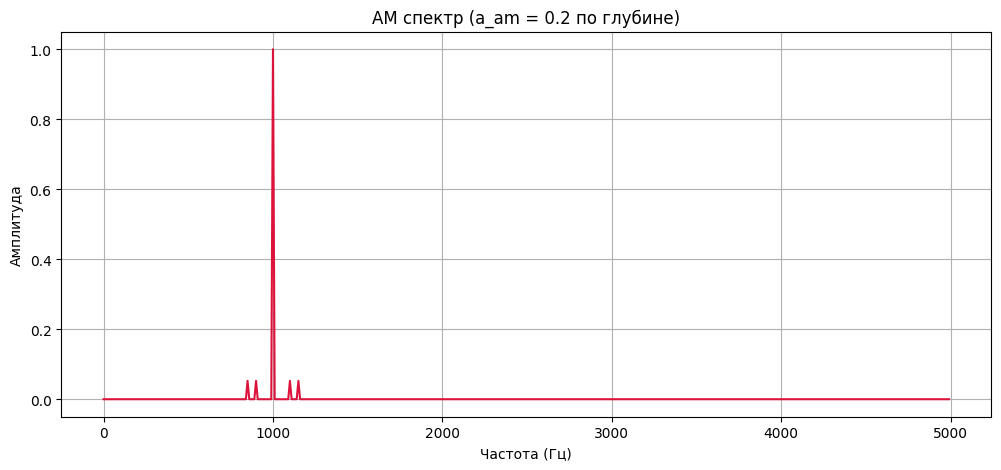

In [152]:
plot_spectrum(s_am, fs, f'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

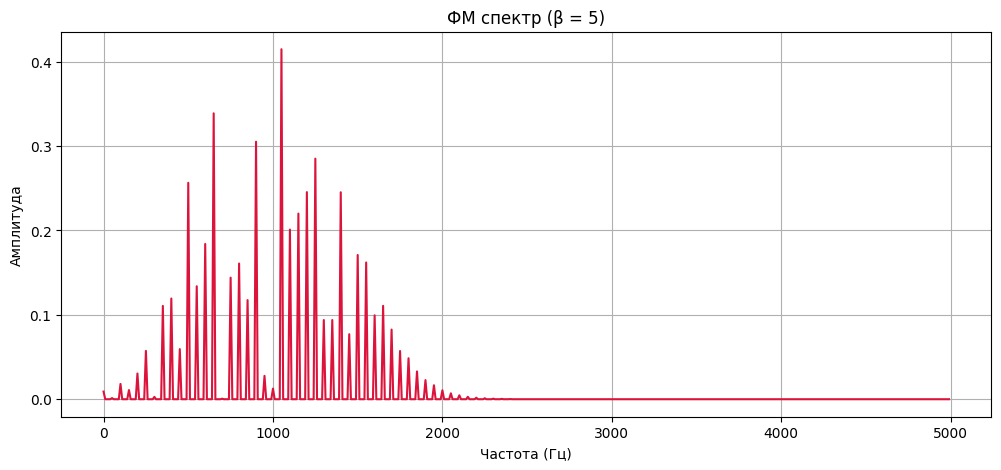

In [153]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

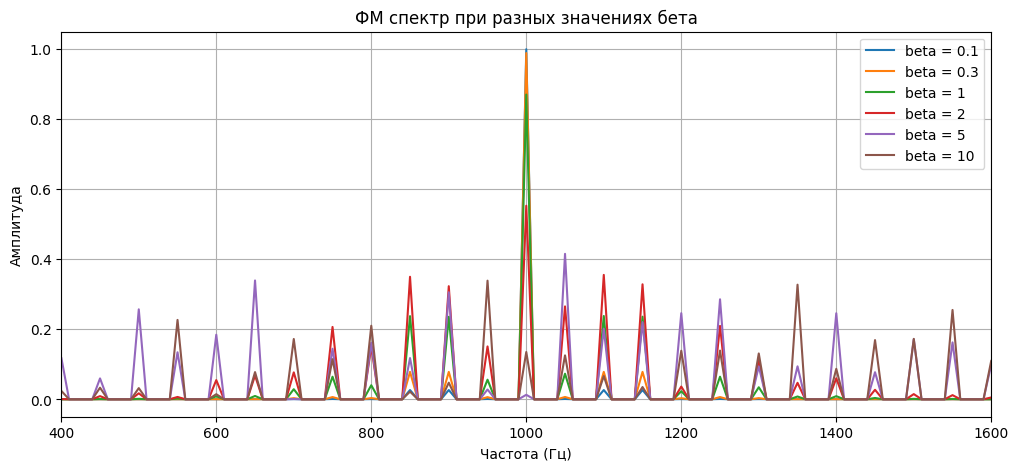

In [154]:
def plot_fm_spectrum(beta_indexes, signals, fs, fc, name_plt):
  for beta in beta_indexes:
    s_pm = 1 * np.cos(2*np.pi*fc*t + beta * signals)
    N = len(s_pm)
    X = np.fft.fft(s_pm)
    freq = np.fft.fftfreq(N, d=1/fs)
    half = N // 2
    freq_pos = freq[:half]
    X_mag = (2.0 / N) * np.abs(X[:half])
    plt.plot(freq_pos, X_mag,  label=f'beta = {beta}', linewidth=1.5)

  plt.title(name_plt)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.grid(True)
  plt.legend()
  plt.xlim(fc -600, fc +600)
  plt.show()

beta_indexes = [0.1, 0.3, 1, 2, 5, 10]
plot_fm_spectrum(beta_indexes, m_t, fs, fc, "ФМ спектр при разных значениях бета")

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [155]:
from ipywidgets import interact, FloatSlider

def pm_spectrum(beta=5):
  s_pm = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
  plot_spectrum(s_pm, fs, f'ФМ спектр (beta = {beta})')

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

1. Сигнал m(t) состоит из частот 100 и 150 Гц. Спектр содержит несущую и боковые полосы ($±100$ Гц и $\pm150$ Гц от несущей)
2. При малых значениях $\beta$ спектр ФМ похож на АМ, т.к. в основном состоит из несущей и ближних к нему гармоник.
3. Уменьшается амплитуда несущей, количество боковых полос увеличивается.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

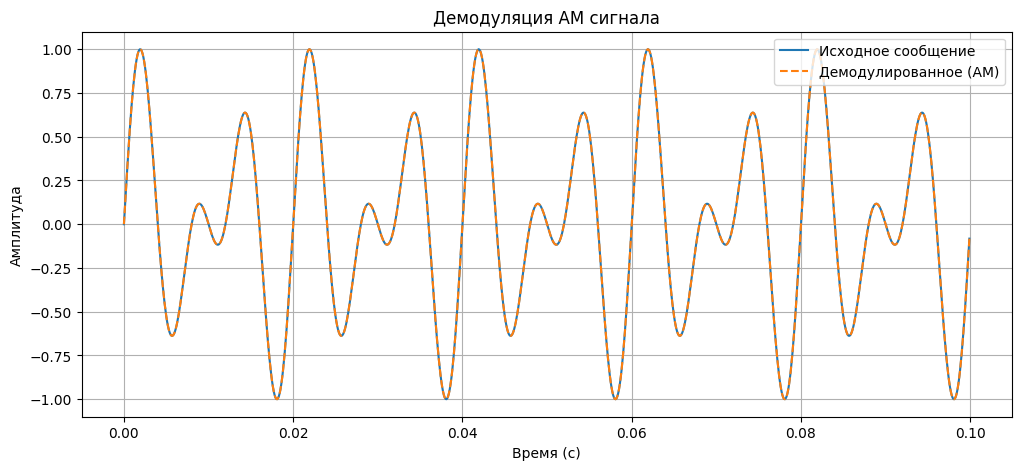

In [156]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [157]:
error = np.std(m_t - demod_am)
print(f'СКО = {error:.4f}')

СКО = 0.0000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

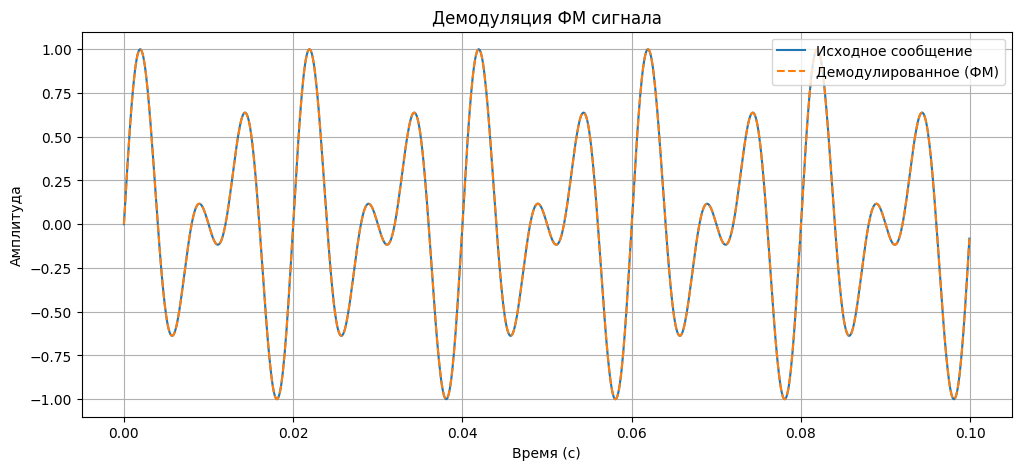

In [158]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

`np.unwrap` важно использовать, потому функция `np.angle` ограничена диапазоном $[-\pi, \pi]$, и когда фаза пересекает этот диапазон, то возникают скачки на $2\pi$.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [159]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"
#!wget -O audio.wav "https://github.com/Uzema/dsp-seminars/raw/refs/heads/nikolaev_lab2/data/sample-3s.wav"

--2026-03-30 12:47:14--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-03-30 12:47:15--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.04s   

2026-03-30 12:47:15 (12.5 MB/s) - ‘audio.wav’ saved [563756/563756]



In [160]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

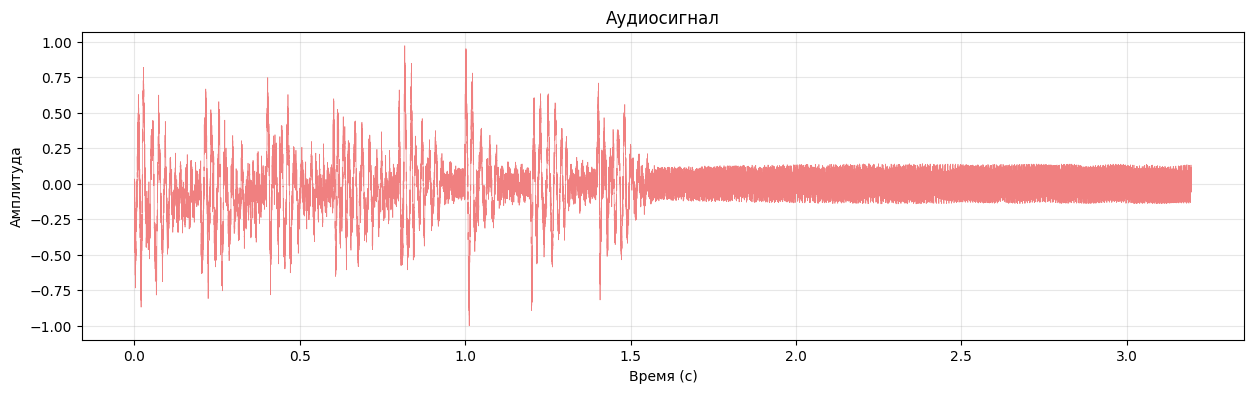

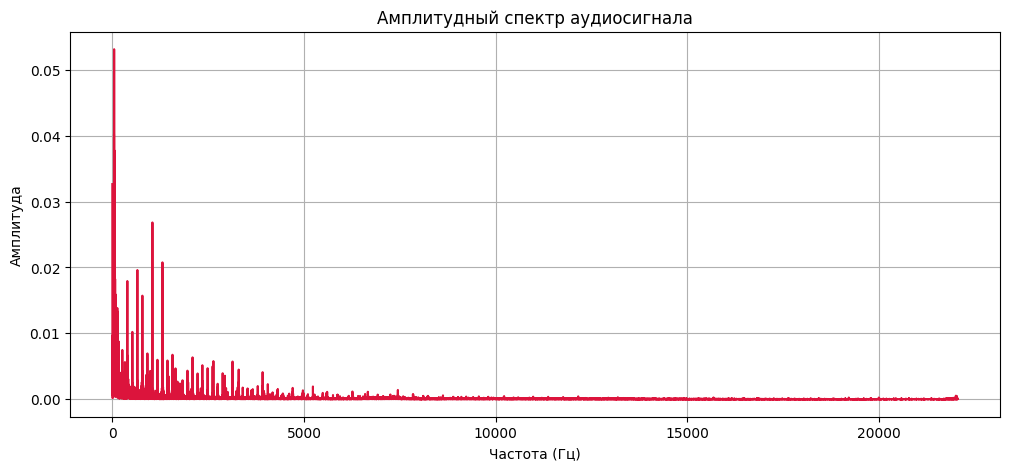

In [161]:
plt.figure(figsize=(15, 4))
plt.plot(t_audio, melody, color='lightcoral', linewidth=0.5)
plt.title('Аудиосигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.show()

plot_spectrum(melody, fs_audio, "Амплитудный спектр аудиосигнала")

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

Заметные пики наблюдаются до ~4 кГц. \
При частоте дискретизации 44,1 кГц частота Найквиста составляет 22,05 кГц. После 10 кГц амплитуда мала, поэтому оптимально будет выбрать частоту между 10-15 кГц. \
В ФМ-сигнале ширина полосы частот определяется правилом Карсона, тоесть при увеличении индекса $\beta$ увеличивается ширина спектра. При больших $\beta$ спектр может выйти за пределы Найквиста и произойдет алиасинг.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [162]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [163]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [164]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [165]:
envelope = np.abs(hilbert(s_am_audio))
m_recovered = (envelope / Ac - 1)/a_am

mse = np.std(melody - m_recovered)

print(f'СКО: {mse:.6f}')
display(Audio(m_recovered, rate=fs_audio))

СКО: 0.011140


Демодулируйте зашумлёный АМ-сигнал.

In [166]:
envelope = np.abs(hilbert(s_am_noisy))
m_noisy_recovered = (envelope / Ac - 1)/a_am

mse = np.std(melody - m_noisy_recovered)

print(f'СКО: {mse:.6f}')
display(Audio(m_noisy_recovered, rate=fs_audio))



СКО: 0.388642


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

1. Качество звука изменилось. При восстановлении сигнала без помех изменение качества едва ли заметно, при востановлении сигнала с помехами в итоге слышно только шумы, что можно заметить по возросшему СКО.
2. При амплитуде 0,05 все еще много шумов, но можно различить мелодию. При 0,01 мелодия вполне ясно слышна, но шум на фоне все еще присутствует.
3. При малых $a_{AM}$ шум слышен более отчетливо. При более высоких значениях (0.5-1) искажения становятся не такими заметными.

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [167]:
analytic = hilbert(s_pm_audio)
instant_phase = np.unwrap(np.angle(analytic))
melody_restored = (instant_phase - 2 * np.pi * fc_high * t_audio) / beta_pm_audio

mse = np.mean(melody - melody_restored)
print(f'MSE: {mse:.6f}')
display(Audio(melody_restored, rate=fs_audio))


MSE: 0.000037


Демодулируйте зашумлёный ФМ-сигнал.

In [168]:
analytic = hilbert(s_pm_noisy)
instant_phase = np.unwrap(np.angle(analytic))
melody_noisy_restored = (instant_phase - 2 * np.pi * fc_high * t_audio) / beta_pm_audio

mse = np.mean(melody - melody_noisy_restored)
print(f'MSE: {mse:.6f}')
display(Audio(melody_noisy_restored, rate=fs_audio))


MSE: 0.000046


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

1. Не значительно.
2. При значении амплитуды шума 0,02 разница с оригиналом слышна.
3. Увеличение индекса модуляции $\beta$ приводит к уменьшению шумов.

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

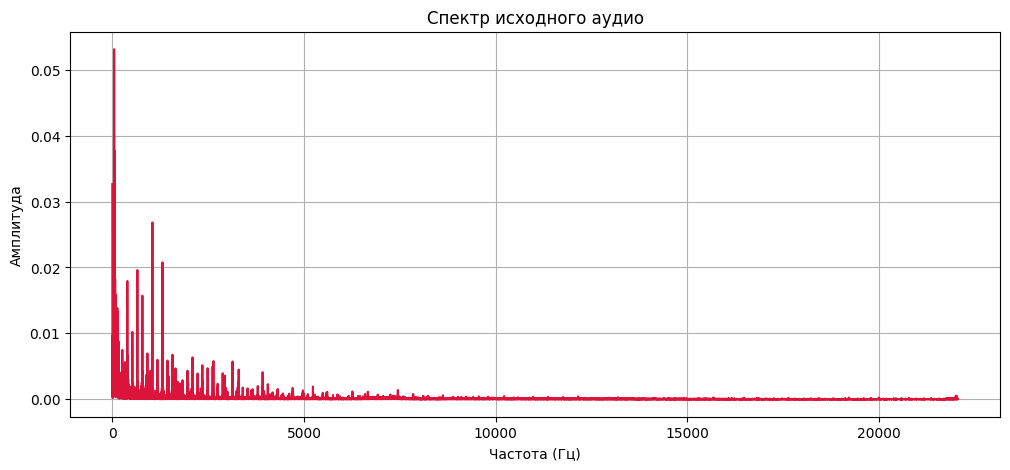

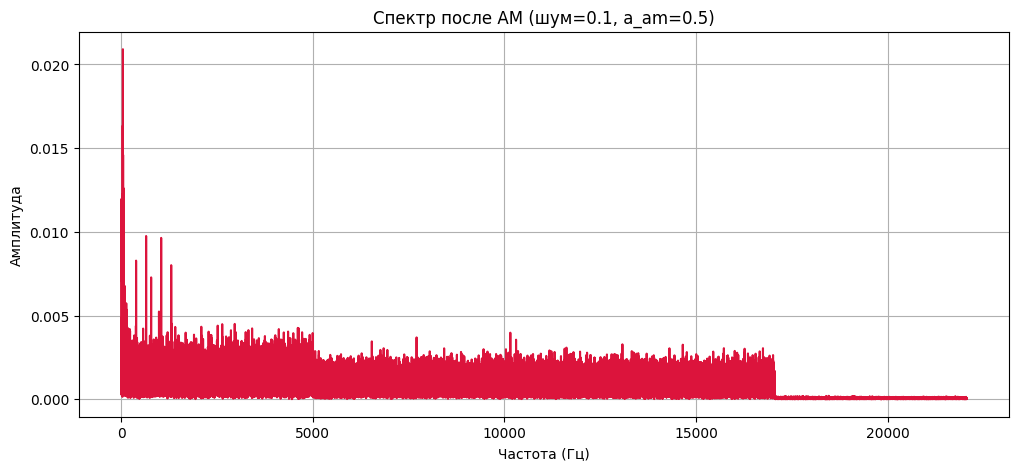

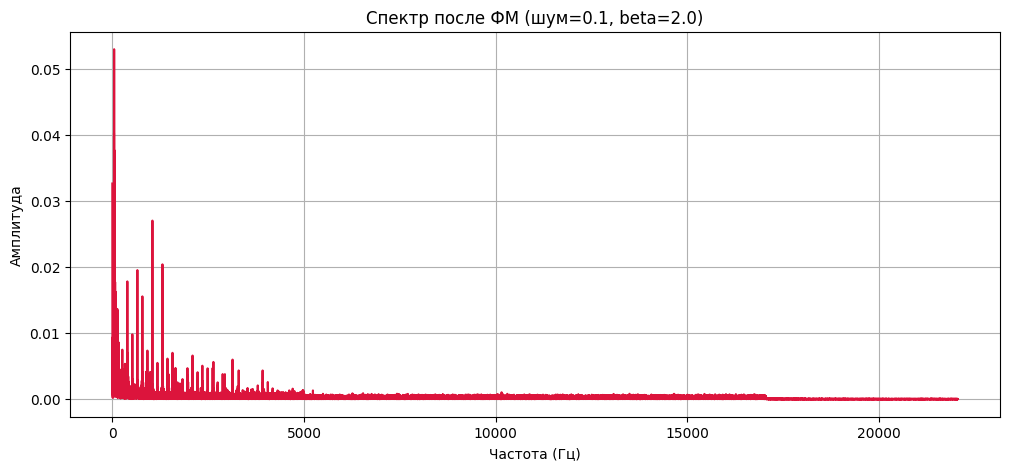

In [172]:
a_am_val = 0.5
beta_val = 2.0
noise_level = 0.1

noise = noise_level * np.random.randn(len(t_audio))

s_am_new_noisy = s_am_audio + noise
s_pm_new_noisy = s_pm_audio + noise

envelope = np.abs(hilbert(s_am_new_noisy))
m_noisy_recovered = (envelope / Ac - 1)/a_am_val

analytic = hilbert(s_pm_new_noisy)
instant_phase = np.unwrap(np.angle(analytic))
melody_noisy_restored = (instant_phase - 2 * np.pi * fc_high * t_audio) / beta_val

plot_spectrum(melody, fs_audio, 'Спектр исходного аудио')
plot_spectrum(m_noisy_recovered, fs_audio, f'Спектр после АМ (шум={noise_level}, a_am={a_am_val})')
plot_spectrum(melody_noisy_restored, fs_audio, f'Спектр после ФМ (шум={noise_level}, beta={beta_val})')

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

Для АМ заметны, для ФМ не значительно.

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

{Введите ваш ответ здесь}